In [1]:
import warnings
warnings.filterwarnings("ignore")
import regional_mom6 as rmom6

import os
from pathlib import Path
from dask.distributed import Client
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cftime

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 1
Total threads: 1,Total memory: 7.81 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44021,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34545,Total threads: 1
Dashboard: http://127.0.0.1:45105/status,Memory: 7.81 GiB
Nanny: tcp://127.0.0.1:45731,


Specifying the home directory:

In [3]:
path = "/scratch/gpfs/CDEUTSCH/wchu/"

## Grid setup

### Topography file `topog.nc`

Initially, working with the seamount configuration, we crop the dataset to match the geometry (40 x 2): 
```
ds.h.isel(ny=slice(5,7),nx=slice(140,180))
```
Now that we are trying a larger domain, use
```
ds.h.isel(ny=slice(5,55),nx=slice(140,240))
```
to match the aspect ratio of the final run.

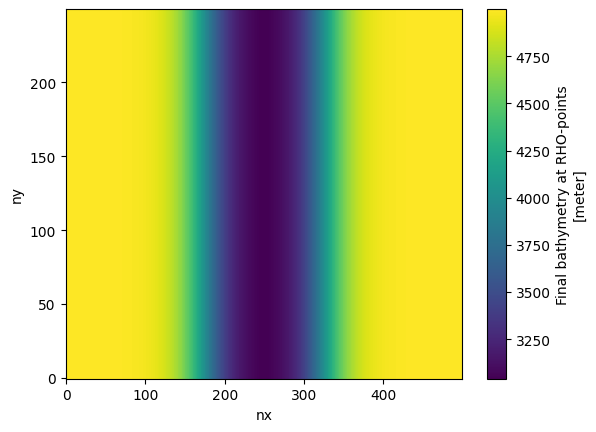

In [12]:
ds = xr.open_dataset(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_grid.nc")
ds = ds.rename_dims({'xi_rho':'nx','eta_rho':'ny'}) # Name dimensions same as in topog.nc file
# topog = ds.h.isel(ny=slice(5,105),nx=slice(140,340)).rename('depth') # Fake topography
topog = ds.h.isel(nx=slice(1,-1),ny=slice(1,-1)).rename('depth')  # Crop edges to match MOM6 grid
topog.plot(x='nx',y='ny')
topog.to_netcdf(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/topog.nc")

### Vertical resolution `thickness.nc`

In [7]:
ds = xr.open_dataset(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_init.nc") # Initialization in NEPTUNE
topog = xr.open_dataset(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/topog.nc")       # Topography file, generated above

eta = (topog.depth*ds.Cs_w[::-1])   # Cs_w is normalized interface height from -1 to 0, take absolute value
eta = eta.rename({'s_w':'nz'})        # Rename the coordinates
eta = eta.to_dataset(name='eta')      # Name the variable, MOM6 is expecting 'eta'
eta = eta.transpose('nz','ny','nx')   # Switch order of dimensions since MOM6 is expecting [nz,ny,nx]
# eta.to_netcdf(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/thickness.nc")

### Setting layer coordinates `layer_coord.nc`

In [14]:
# ds = xr.open_dataset(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_init.nc") # initialization in NEPTUNE
np.abs(ds.Cs_w[::-1]).diff(dim='s_w')
# layer = (np.abs(ds.Cs_r))                                   # Cs_r is normalized layer height from -1 to 0, take absolute value
# layer = layer[::-1].rename({'s_rho':'zl'}).rename('Layer')  # Rename vertical coordinate and variable name
# interface = (np.abs(ds.Cs_w))
# interface = interface[::-1].rename({'s_w':'zi'}).rename('Interface')
# layer_coord = xr.merge([layer,interface])
# layer_coord.to_netcdf(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/layer_coord.nc")

<xarray.DataArray 'Cs_w' (s_w: 80)> Size: 640B
array([0.00018696, 0.00056141, 0.00093742, 0.00131602, 0.00169826,
       0.00208515, 0.00247773, 0.00287698, 0.00328391, 0.00369949,
       0.00412467, 0.00456038, 0.00500751, 0.00546691, 0.00593939,
       0.00642572, 0.00692658, 0.00744258, 0.00797426, 0.00852206,
       0.0090863 , 0.00966715, 0.01026468, 0.01087874, 0.01150905,
       0.01215506, 0.01281604, 0.01349097, 0.01417856, 0.0148772 ,
       0.01558496, 0.01629953, 0.01701822, 0.01773792, 0.0184551 ,
       0.01916577, 0.01986546, 0.02054926, 0.02121175, 0.02184707,
       0.02244893, 0.02301062, 0.02352506, 0.02398491, 0.02438262,
       0.02471052, 0.02496098, 0.02512656, 0.02520014, 0.02517515,
       0.02504576, 0.02480709, 0.02445546, 0.02398861, 0.02340592,
       0.02270865, 0.02190004, 0.02098553, 0.0199728 , 0.01887176,
       0.01769452, 0.01645523, 0.01516977, 0.01385545, 0.01253055,
       0.01121377, 0.00992365, 0.00867796, 0.00749303, 0.00638318,
       0.00536018, 0.00443286, 0.00360682, 0.00288433, 0.00226446,
       0.00174329, 0.00131435, 0.00096918, 0.00069797, 0.00049017])
Dimensions without coordinates: s_w

## Initial conditions

### Temperature and salinity `initial_TS.nc`

In [4]:
ds = xr.open_dataset(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_init.nc")

TS = ds[['temp','salt']]
TS = TS.rename({'s_rho':'nz','eta_rho':'ny','xi_rho':'nx'})           # Rename the coordinates
# TS = TS.isel(ny=slice(5,105),nx=slice(140,340),nz=slice(None, None, -1))  # Fake topography
TS = TS.isel(nx=slice(1,-1),ny=slice(1,-1))#,nz=slice(None, None, -1))  # Crop edges, reverse order of vertical
TS.to_netcdf(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/initial_TS.nc")

### Random wind surface forcing `surface_frc.nc`

In [10]:
surface_frc = xr.open_dataset(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_frc.nc")
surface_frc = surface_frc[["sustr","svstr","swrad"]]
surface_frc = surface_frc.rename({'xi_rho':'xh','eta_rho':'yh','xi_u':'xq','eta_v':'yq'})

surface_frc['frc_time'] = xr.date_range(start=cftime.DatetimeJulian(1,1,1,1,0,0,0), periods=surface_frc.frc_time.size, freq="D", use_cftime=True, calendar="cftime.DatetimeJulian")
surface_frc = surface_frc.rename({'frc_time':'time'})
surface_frc = surface_frc.isel(xh=slice(140,180),yh=slice(5,25),xq=slice(140,180),yq=slice(5,25)) # Fake topography
# surface_frc = surface_frc.isel(xh=slice(1,-1),yh=slice(1,-1),xq=slice(0,-1),yq=slice(0,-1))
surface_frc.to_netcdf(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/surface_frc.nc",unlimited_dims='time',encoding={"time": {"dtype": "double"}})  

### Scratchwork

In [9]:
# ds = xr.open_dataset(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_init.nc")
# ale_res = (np.abs(ds.Cs_w))[::-1]
# ale_res[1] - ale_res[0]
# print('%.15f' % ale_res.diff('s_w').values)

# for x in ale_res.diff('s_w'):
#         print(f'{x:.15g}')
# ale_res.diff('s_w')

# surface_frc = xr.open_dataset(path+"/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_frc.nc")
# surface_frc.swrad.isel(frc_time=40).plot()

<xarray.Dataset> Size: 7GB
Dimensions:   (frc_time: 1827, eta_rho: 252, xi_u: 501, eta_v: 251, xi_rho: 502)
Coordinates:
  * frc_time  (frc_time) float32 7kB 0.0 1.0 2.0 ... 1.825e+03 1.826e+03
Dimensions without coordinates: eta_rho, xi_u, eta_v, xi_rho
Data variables:
    sustr     (frc_time, eta_rho, xi_u) float32 923MB ...
    svstr     (frc_time, eta_v, xi_rho) float32 921MB ...
    shflux    (frc_time, eta_rho, xi_rho) float32 924MB ...
    swflux    (frc_time, eta_rho, xi_rho) float32 924MB ...
    SST       (frc_time, eta_rho, xi_rho) float32 924MB ...
    SSS       (frc_time, eta_rho, xi_rho) float32 924MB ...
    dQdSST    (frc_time, eta_rho, xi_rho) float32 924MB ...
    swrad     (frc_time, eta_rho, xi_rho) float32 924MB ...

In [58]:
surface_frc = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_frc.nc")
surface_frc = surface_frc[["sustr","svstr"]].isel(xi_rho=slice(140,180),eta_rho=slice(5,7),xi_u=slice(140,180),eta_v=slice(5,7))
surface_frc = surface_frc.rename({'xi_rho':'xh','eta_rho':'yh','xi_u':'xq','eta_v':'yq'})
# surface_frc = surface_frc.isel(frc_time=slice(0,240))
# ds = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/prog.nc")
# ds['sustr'] = (('time', 'yh', 'xq'), surface_frc.sustr.values)
# ds['svstr'] = (('time', 'yq', 'xh'), surface_frc.svstr.values)
# ds[["sustr","svstr"]].isel(xq=slice(0,-1),yq=slice(0,-1)).to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/surface_frc.nc")#,unlimited_dims='time')

ds = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/prog.nc")
surface_frc['frc_time'] = xr.date_range(start=ds.time.values[0], periods=surface_frc.frc_time.size, freq="D", use_cftime=True, calendar="cftime.DatetimeJulian")
surface_frc = surface_frc.rename({'frc_time':'time'})
surface_frc.to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/surface_frc.nc")
# surface_frc
# Layer = (np.abs(ds.Cs_r))# Cs_w is normalized interface height from 0 to 1
# Layer = Layer[::-1].rename({'s_rho':'nk'}).rename('Layer')
# Layer.to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/ts_profile.nc")

# eta = eta.rename({'s_w':'nz'}) # rename the coordinates
# eta = eta.to_dataset(name='eta')
# eta = eta.transpose('nz','ny','nx')
# ds.temp.isel(eta_rho=40).plot(x='xi_rho',y='s_rho')

# ds = ds[['temp','salt']]
# ds = ds.rename({'s_rho':'nz','eta_rho':'ny','xi_rho':'nx'})
# ds = ds.isel(nx=slice(1,-1),ny=slice(1,-1),nz=slice(None, None, -1)) # fake topography
# ds.to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/initial_TS.nc")

In [10]:
# surface_frc = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_frc.nc")
# surface_frc = surface_frc[["sustr","svstr"]]
# surface_frc = surface_frc.rename({'xi_rho':'xh','eta_rho':'yh','xi_u':'xq','eta_v':'yq'})

# surface_frc['frc_time'] = xr.date_range(start=cftime.DatetimeJulian(1,1,1,1,0,0,0), periods=surface_frc.frc_time.size, freq="D", use_cftime=True, calendar="cftime.DatetimeJulian")
# surface_frc = surface_frc.rename({'frc_time':'time'})
surface_frc.isel(xh=slice(140,180),yh=slice(5,7),xq=slice(140,180),yq=slice(5,7)).to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/surface_frc.nc",unlimited_dims='time',encoding={"time": {"dtype": "double"}})

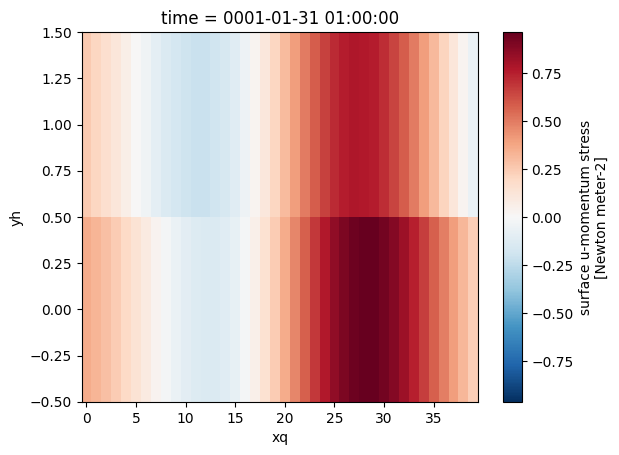

In [12]:
# ds.swrad.isel(frc_time=400).plot()
# str(ds.time.values[0])
# ds.time.values[0]
# ds.frc_time.size
# surface_frc.drop_dims('frc_time')#.drop_vars('frc_time')
# test = xr.date_range(start=ds.time.values[0], periods=6, freq="D", use_cftime=True, calendar="cftime.DatetimeJulian")
# ds.time.values[0]
# xr.date_range(start=cftime.DatetimeJulian(1, 1, 1, 1, 0, 0, 0), periods=1746, freq="D", use_cftime=True, calendar="cftime.DatetimeJulian")
# import cftime

# datetime(1, 1, 1, 1, 0, 0).astype('cftime._cftime.DatetimeJulian')#.strftime('%j')
# surface_frc = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_frc.nc")
surface_frc.isel(xh=slice(140,180),yh=slice(5,7),xq=slice(140,180),yq=slice(5,7)).sustr.isel(time=30).plot()

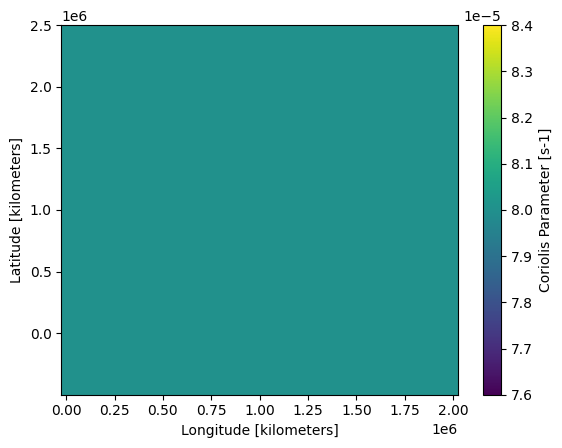

In [27]:
# topog = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/topog.nc")
# eta = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/thickness.nc")
# -1*topog.depth.values + eta.eta[::-1,:,:].isel(nz=80).values

# eta.eta.isel(nz=80).values
# eta = eta.isel(nz=slice(None, None, -1))#.isel(nz=80).values
# eta
# eta_new = eta.reindex(nz=eta.nz[::-1])

# ds = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/Vertical_coordinate.nc")
# ds.temp.isel(ny=0).plot(x='nx',y='nz')
# ds.f.plot(x='lonq',y='latq')

In [31]:
ds = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_init.nc") # initialization in NEPTUNE
topog = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/topog.nc")       # topography file, generated above

eta = (topog.depth*np.abs(ds.Cs_w))   # Cs_w is normalized interface height from -1 to 0, take absolute value
eta = eta.rename({'s_w':'nz'})        # Rename the coordinates
eta = eta.to_dataset(name='eta')      # Name the variable, MOM6 is expecting 'eta'
eta = eta.transpose('nz','ny','nx')   # Switch order of dimensions since MOM6 is expecting [nz,ny,nx]
eta.to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/thickness.nc")

In [189]:
ds = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_init.nc")

# interface height
# LENLAT = 2000000.0 # MOM_input parameter
# NIGLOBAL = 40 # MOM_input parameter
# lonh = LENLAT/(2*NIGLOBAL) + LENLAT/NIGLOBAL*topog.nx
# LENLON = LENLAT # MOM_input parameter
# NJGLOBAL = 2 # MOM_input parameter
# SOUTHLAT = 30
# lath = SOUTHLAT + LENLON/(2*NJGLOBAL) + LENLON/NJGLOBAL*topog.ny

# eta = eta.to_dataset(name='eta')
# eta = eta.transpose('nz','ny','nx')

topog = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/topog.nc")
eta = (topog.depth*np.abs(ds.Cs_w))# Cs_w is normalized interface height from 0 to 1
eta = eta.rename({'s_w':'nz'}) # rename the coordinates
eta = eta.to_dataset(name='eta')
eta = eta.transpose('nz','ny','nx')
# eta = eta.assign_coords({'Interface':np.abs(-1*ds.Cs_w)}).swap_dims({'s_w':'nz'})#.isel(ny=0).plot(x='lonh',y='Interface')
eta.to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/thickness.nc")
# eta = eta.drop_vars('Interface')

# eta
# assign coords with common values, xi_psi = xq (lonq), eta_psi = yq (latq), xi_rho = xh (lonh), eta_rho = yh (lath)
# xi_u = xi_psi, eta_u = eta_rho, xi_v = xi_rho, eta_v = eta_psi 
# ds.xi_u.values - ds.xi_psi.values # will produce a vector of 0s

# ds = ds.swap_dims({'xi_u':'xi_psi','eta_v':'eta_psi'}).rename_dims({'xi_psi':'lonq','eta_psi':'latq','xi_rho':'lonh','eta_rho':'lath','s_rho':'Layer','s_w':'Interface'})
# ds = ds.isel(lath=slice(1,-1),lonh=slice(1,-1)) # crop the edges of the grid (extra points in ROMS compared to MOM6)
# ds = ds.expand_dims(dim={"Time": np.array([0]).astype('timedelta64[ns]')},axis=0)
# ds = ds.assign_coords({'Layer':ds.Layer,'lath':ds.lath,'lonh':ds.lonh,'lonq':ds.lonq,'latq':ds.latq,'Interface':ds.Interface})

In [12]:
# ds = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/neptune_init.nc")
# ds.Cs_w.diff(dim='s_w')
# ds
# ds.temp.isel(eta_rho=50,xi_rho=50).plot()
ds.Cs_w

<xarray.DataArray 'Cs_w' (s_w: 81)> Size: 648B
[81 values with dtype=float64]
Dimensions without coordinates: s_w
Attributes:
    long_name:  S-coordinate stretching curves at W-points
    units:      nondimensional
    valid_min:  -1.0
    valid_max:  0.0
    field:      Cs_w, scalar

In [153]:
# ds.Cs_r.plot()
# plt.plot(range(80),test)

# ds.Cs_r.values - test


# h = eta[:,:,1:].values - eta[:,:,0:-1].values # layer thicknesses
# h[:,:,::-1]
# test = test[:,:,1:] # rolling mean shifts right, so we can shift one
# test = np.abs(test)
# test.sum('s_w')
# h.shape
# ds

# eta = (topog.depth*0).rename('eta')#ds.Cs_w
# eta = eta.assign_coords({'ny':da.ny.astype('int'),'nx':da.nx.astype('int')})
# da = xr.DataArray(h[:,:,::-1], dims=('ny','nx','nz'))
# da = da.rename('h')
# da = da.assign_coords({'ny':da.ny,'nx':da.nx,'nz':da.nz})
# da.to_dataset()
# da = da.transpose('nx','ny','nz')
# da = da.drop_vars(['nx','ny','nz'])
# thickness = xr.merge([eta,da])
# da.to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/INPUT/thickness.nc")

# da.ny#.astype('int')

In [171]:
# ds['Cs_r'] = np.abs(-1*ds.Cs_r[::-1]) # reverse order and flip sign for MOM6 convention
# ds['Cs_w'] = np.abs(-1*ds.Cs_w[::-1]) # reverse order and flip sign for MOM6 convention
# thickness = ds[['Cs_r','Cs_w']].rename({'Cs_r':'Layer','Cs_w':'Interface'})
# thickness = thickness.swap_dims({'s_rho':'Layer','s_w':'Interface'})
# thickness.to_netcdf("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/NEPTUNE/thickness.nc")
# ds

# ds.rename({'temp':'Temp','salt':'Salt','Cs_r':'Layer','Cs_w':'Interface'}).drop_vars(['ocean_time','Tcline','hc'])
# ds
# ds.Cs_r

<xarray.DataArray 'eta' (ny: 2, nx: 40, s_w: 81)> Size: 52kB
array([[[-4.99914780e+03, -4.99669738e+03, -4.99320812e+03, ...,
         -3.74121922e+00, -9.34654202e-01,  0.00000000e+00],
        [-4.99910113e+03, -4.99665073e+03, -4.99316151e+03, ...,
         -3.74118429e+00, -9.34645478e-01,  0.00000000e+00],
        [-4.99905192e+03, -4.99660154e+03, -4.99311235e+03, ...,
         -3.74114746e+00, -9.34636276e-01,  0.00000000e+00],
        ...,
        [-4.99388475e+03, -4.99143691e+03, -4.98795132e+03, ...,
         -3.73728050e+00, -9.33670209e-01,  0.00000000e+00],
        [-4.99355083e+03, -4.99110315e+03, -4.98761780e+03, ...,
         -3.73703060e+00, -9.33607778e-01,  0.00000000e+00],
        [-4.99319873e+03, -4.99075122e+03, -4.98726612e+03, ...,
         -3.73676710e+00, -9.33541949e-01,  0.00000000e+00]],

       [[-4.99914780e+03, -4.99669738e+03, -4.99320812e+03, ...,
         -3.74121922e+00, -9.34654202e-01,  0.00000000e+00],
        [-4.99910113e+03, -4.99665073e+03, -4.99316151e+03, ...,
         -3.74118429e+00, -9.34645478e-01,  0.00000000e+00],
        [-4.99905192e+03, -4.99660154e+03, -4.99311235e+03, ...,
         -3.74114746e+00, -9.34636276e-01,  0.00000000e+00],
        ...,
        [-4.99388475e+03, -4.99143691e+03, -4.98795132e+03, ...,
         -3.73728050e+00, -9.33670209e-01,  0.00000000e+00],
        [-4.99355083e+03, -4.99110315e+03, -4.98761780e+03, ...,
         -3.73703060e+00, -9.33607778e-01,  0.00000000e+00],
        [-4.99319873e+03, -4.99075122e+03, -4.98726612e+03, ...,
         -3.73676710e+00, -9.33541949e-01,  0.00000000e+00]]])
Dimensions without coordinates: ny, nx, s_w

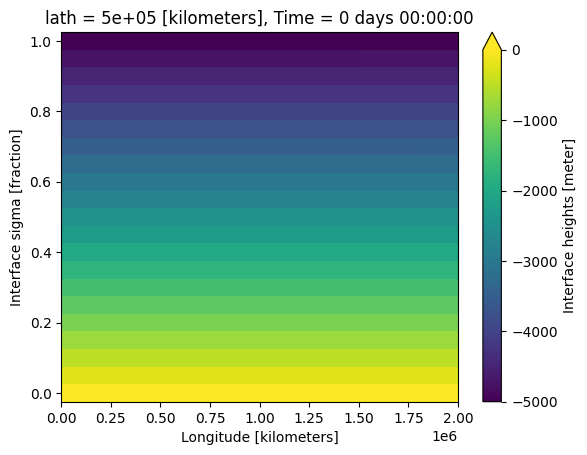

In [118]:
# dsnow = xr.open_dataset("/scratch/gpfs/CDEUTSCH/wchu/MOM6-examples-topo/ocean_only/seamount/sigma/Initial_state.nc")
# dsnow
# dsnow.h.cumsum('Layer').isel(Time=0,lath=0).plot(x='lonh',y='Layer')
# dsnow.eta.isel(Time=0,lath=0).plot(x='lonh',y='Interface',vmin=-5000,vmax=0)
# Z_rho = zeta + (zeta + H) * S_rho